In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sys
import re
from PIL.ImageColor import colormap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit
from pathlib import Path

In [5]:
# --------------- Set up project root path  --------------- #
project_folder_name = "MFC2024" # Set this to the name of your project root folderS
project_root = next((p for p in [Path.cwd(), *Path.cwd().parents] if p.name == project_folder_name), None)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from config.settings import *
from model.dynamic import PEMFC_dyn
from model.coefficients import *
from config.initialize import *
from config.settings import *

In [6]:
# ---- Validation run: small grid, robust per-point error handling ----
# The dynamic model (181 states, full BoP) is ~5 s wall per simulated second
# at default mesh, so the full 9-condition x 7-current x 600-s grid would
# take ~5 hours. For an INITIAL validation run we use a reduced subset
# (1 condition, 3 currents, t_span = 30 s) so we can confirm the model
# produces sensible polarisation values in ~5 minutes. After this baseline
# is confirmed, expand the grid for a production run.
import time as _time

pola_tests_sim = {}
load_points    = [10, 20, 30, 35, 40, 45, 50]   # full sweep for reference plots
# Validation subset -- comment the next 3 lines out for the full grid
_VALIDATION_RHC = [0.5]
_VALIDATION_P   = [1.4]               # bar (was [1.3, 1.4, 1.5])
_VALIDATION_T   = [333.15]            # K   (was [323.15, 333.15, 343.15])
_VALIDATION_I   = [10, 30, 50]        # A   (was load_points)

T_SPAN = (0, 30)                      # was (0, 600); 30 s is enough for steady-state Ucell
MAX_STEP = 1e-1

t0_total = _time.perf_counter()
for RHC in _VALIDATION_RHC:
    for P_des in _VALIDATION_P:
        for T_des in _VALIDATION_T:
            cond_key = f"RHC{RHC}_P{P_des}_T{T_des}"
            print(f"\n=== {cond_key} ===")
            states_test = []           # list of dicts (one per successful current)
            i_kept      = []
            for I_LOAD in _VALIDATION_I:
                op = dict(operating_inputs)
                op["Phi_c_des"] = RHC
                op["Pa_des"]    = P_des * 1e5
                op["Pc_des"]    = P_des * 1e5
                op["Tfc"]       = T_des
                op["current_density"] = (lambda x, _I=I_LOAD: _I / parameters["Aact"])

                t0 = _time.perf_counter()
                try:
                    x_init = init_x_for("dynamic", op, parameters)
                    if RHC == 0:
                        x_init[model_dummy_var_names.index("Wc_inj") if False else 0] = 0.0
                    # Use the same initial state both for model construction and the solver
                    model = PEMFC_dyn(parameters, op, x_init)
                    # Override Wc_inj setpoint by name (works for non-zero RHC)
                    if RHC > 0:
                        idx_wc = model.solver_variable_names.index("Wc_inj")
                        x_init[idx_wc] = 4.0e-5
                    sol = solve_ivp(model.dxdt, T_SPAN, x_init,
                                    method="BDF", max_step=MAX_STEP)
                    if not sol.success:
                        print(f"  I = {I_LOAD:5.1f} A  ->  solver failed: {sol.message}")
                        continue
                    model._recovery(sol)
                    # Gather last-step values from both variables and ec_kinetics
                    states = {}
                    for var_name in model.variables:
                        v = model.variables[var_name]
                        states[var_name] = v[-1] if hasattr(v, "__len__") and len(v) else float("nan")
                    for var_name in model.ec_kinetics:
                        v = model.ec_kinetics[var_name]
                        states[var_name] = v[-1] if hasattr(v, "__len__") and len(v) else float("nan")
                    # Reject if Ucell is non-finite or unphysical
                    u = states.get("Ucell", float("nan"))
                    try:
                        u = float(u)
                    except Exception:
                        u = float("nan")
                    if not (np.isfinite(u) and 0.0 < u < 1.3):
                        print(f"  I = {I_LOAD:5.1f} A  ->  unphysical Ucell = {u}")
                        continue
                    states_test.append(states)
                    i_kept.append(I_LOAD)
                    print(f"  I = {I_LOAD:5.1f} A  ->  Ucell = {u:.3f} V"
                          f"   ({_time.perf_counter() - t0:.1f} s wall)")
                except Exception as exc:
                    print(f"  I = {I_LOAD:5.1f} A  ->  {type(exc).__name__}: {exc}")

            if not states_test:
                print(f"  -> {cond_key}: no successful points, skipping")
                continue

            # Pack into the same shape the downstream cells expect:
            # {cond_key: {"states": {var_name: [val_per_i]}}}
            states_profile = {var: [s.get(var, float("nan")) for s in states_test]
                              for var in states_test[0].keys()}
            states_profile["_i_kept"] = i_kept
            pola_tests_sim[cond_key] = {"states": states_profile, "i_kept": i_kept}

print(f"\nDone. {len(pola_tests_sim)} condition(s) with "
      f"successful points. Total wall time: {_time.perf_counter() - t0_total:.1f} s")



=== RHC0.5_P1.4_T333.15 ===
  I =  10.0 A  ->  Ucell = 0.882 V   (39.7 s wall)
  I =  30.0 A  ->  Ucell = 0.840 V   (113.7 s wall)
  I =  50.0 A  ->  Ucell = 0.778 V   (126.6 s wall)

Done. 1 condition(s) with successful points. Total wall time: 280.1 s


### Plot HFR

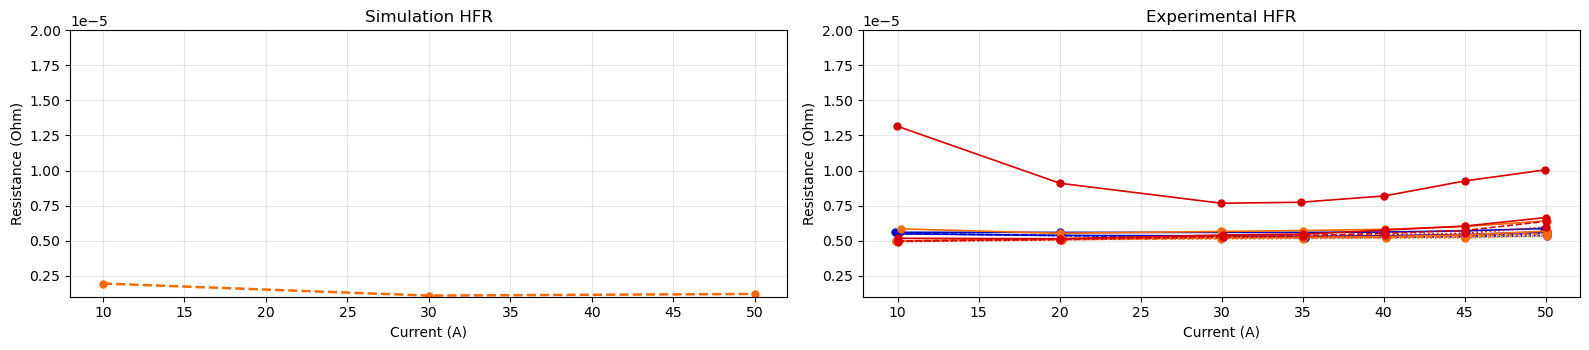

In [7]:
from ast import literal_eval

hfr_data_path = project_root / "data" / "HFR.xlsx"
hfr_testdata = pd.read_excel(hfr_data_path, sheet_name=None)

fig, ax = plt.subplots(figsize=(16, 4), nrows=1, ncols=2)
for key, value in pola_tests_sim.items():
    Rmem = [sum(Rmem_i) for Rmem_i in value["states"]["Rmem"]]
    plot_condition(ax[0], value.get("i_kept", load_points), np.array(Rmem), key, linewidth=1.8)

ax[1].set_ylim(1e-6, 2e-5)
ax[0].set_ylim(ax[1].get_ylim())

for name, data in hfr_testdata.items():
    r_pairs = data["R"].map(literal_eval)
    r_pairs = np.array(r_pairs.tolist(), dtype=float)
    r_values = r_pairs[:, 0]
    i_values = data["I_LOAD"].to_numpy(dtype=float)
    plot_condition(ax[1], i_values, r_values * 30e-4 / (22 * 1e3), name, linewidth=1.2, markersize=5)

ax[0].set_title("Simulation HFR")
ax[0].set_xlabel("Current (A)")
ax[0].set_ylabel("Resistance (Ohm)")
ax[0].grid(True, alpha=0.3)

ax[1].set_title("Experimental HFR")
ax[1].set_xlabel("Current (A)")
ax[1].set_ylabel("Resistance (Ohm)")
ax[1].grid(True, alpha=0.3)

# fig.legend(...) removed -- legend_handles is built only in later cells
plt.tight_layout(rect=(0, 0, 1, 0.9))
plt.show()

### Plot performance

In [8]:
def kinetics(i, x, a_slim, b_slim, a_switch, kappa_c, i0_c_ref, operating_inputs):

    """ 
    This function is dedicated to calibrating the kinetic parameters for the cathode catalyst layer, 
    which are used in the calculation of eta_c. It returns the intermediate values needed for calculating eta_c, 
    including Ueq, f_drop, eta_c, Rohm, and Rccl.
    """
    slim = a_slim * (operating_inputs['Pc_des'] / 1e5) + b_slim
    s_switch = a_switch * slim
    i_fc = np.array(x["i_fc"], dtype=float)
    s_ccl = np.array(x["s_ccl"], dtype=float)
    Tccl = np.array(x["Tccl"], dtype=float)
    C_O2_ccl = np.array(x["C_O2_ccl"], dtype=float)
    C_H2_acl = np.array(x["C_H2_acl"], dtype=float)
    Ueq = (E0 - 8.5e-4 * (Tccl - 298.15) + R * Tccl / (2 * F) * (np.log(R * Tccl * C_H2_acl / Pref) + 0.5 * np.log(R * Tccl * C_O2_ccl / Pref)))
    f_drop = 0.5 * (1.0 - np.tanh((4 * s_ccl - 2 * slim - 2 * s_switch) / (slim - s_switch)))
    i0_c = i0_c_ref * np.exp(-Eact / R * (1 / Tccl - 1 / 353))
    eta_c = (1 / f_drop * R * Tccl / (alpha_c * F) * np.log((i_fc) / i0_c * (C_O2ref / C_O2_ccl) ** kappa_c))
    return Ueq, f_drop, eta_c

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


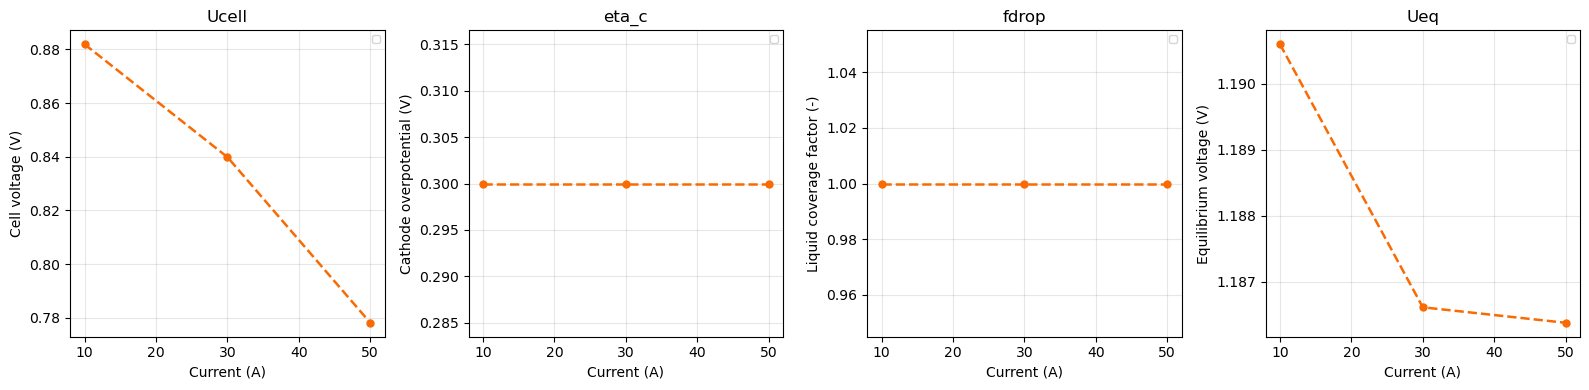

In [9]:
# ---- Cell 7: Simulation summary -- four key trajectories vs current ----
# Direct plotting of what the model recorded -- no kinetics recomputation
# (it was producing inconsistent results with cell 2's saved Ucell).
panels = [
    ("Ucell",  "Cell voltage (V)"),
    ("eta_c",  "Cathode overpotential (V)"),
    ("fdrop",  "Liquid coverage factor (-)"),
    ("Ueq",    "Equilibrium voltage (V)"),
]
fig, axes = plt.subplots(figsize=(16, 4), nrows=1, ncols=len(panels))
for ax, (var, ylabel) in zip(axes, panels):
    for key, value in pola_tests_sim.items():
        i = value.get("i_kept", load_points)
        if var not in value["states"]:
            continue
        y = np.array(value["states"][var], dtype=float)
        plot_condition(ax, i, y, key, linewidth=1.8, markersize=5)
    ax.set_xlabel("Current (A)")
    ax.set_ylabel(ylabel)
    ax.set_title(var)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7, loc="best")
plt.tight_layout()
plt.show()


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


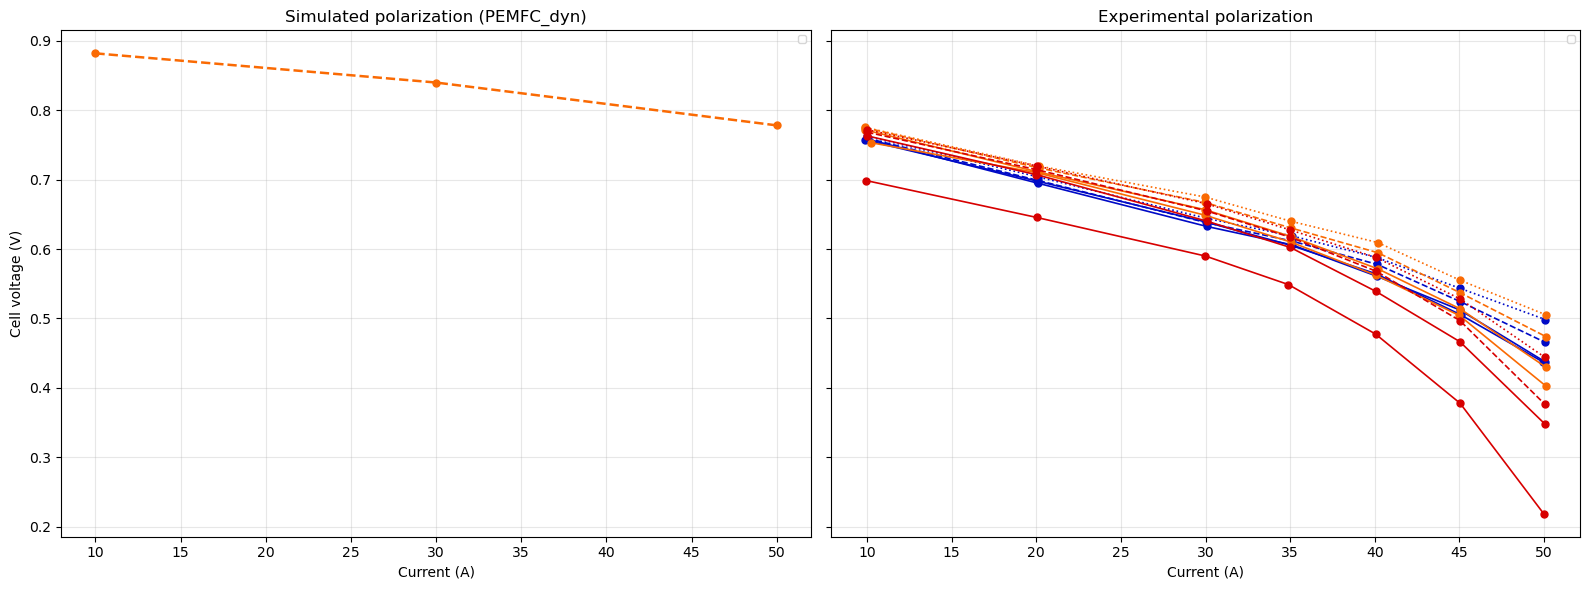

In [10]:
# ---- Cell 8: Polarization curve - simulation vs experiment ----
# We use the Ucell that PEMFC_dyn already computed in cell 2 -- no need
# to reconstruct it from kinetic primitives.
exp_pola_data = pd.ExcelFile(project_root / "data" / "Polar_curves.xlsx")
pola_testdata = {sname: pd.read_excel(exp_pola_data, sheet_name=sname)
                 for sname in exp_pola_data.sheet_names}

fig, ax = plt.subplots(figsize=(16, 6), nrows=1, ncols=2, sharey=True)

# Simulated
for key, value in pola_tests_sim.items():
    i = value.get("i_kept", load_points)
    Ucell = np.array(value["states"]["Ucell"], dtype=float)
    plot_condition(ax[0], i, Ucell, key, linewidth=1.8, markersize=5)

# Experimental
for name, data in pola_testdata.items():
    i_values = data["I_LOAD"].to_numpy(dtype=float)
    v_values = data["VFC"].to_numpy(dtype=float) / n_cell
    plot_condition(ax[1], i_values, v_values, name, linewidth=1.2, markersize=5)

ax[0].set_title("Simulated polarization (PEMFC_dyn)")
ax[1].set_title("Experimental polarization")
ax[0].set_ylabel("Cell voltage (V)")
for a in ax:
    a.set_xlabel("Current (A)")
    a.grid(True, alpha=0.3)
    a.legend(fontsize=7, loc="best")
plt.tight_layout()
plt.show()


### Plot water saturation

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


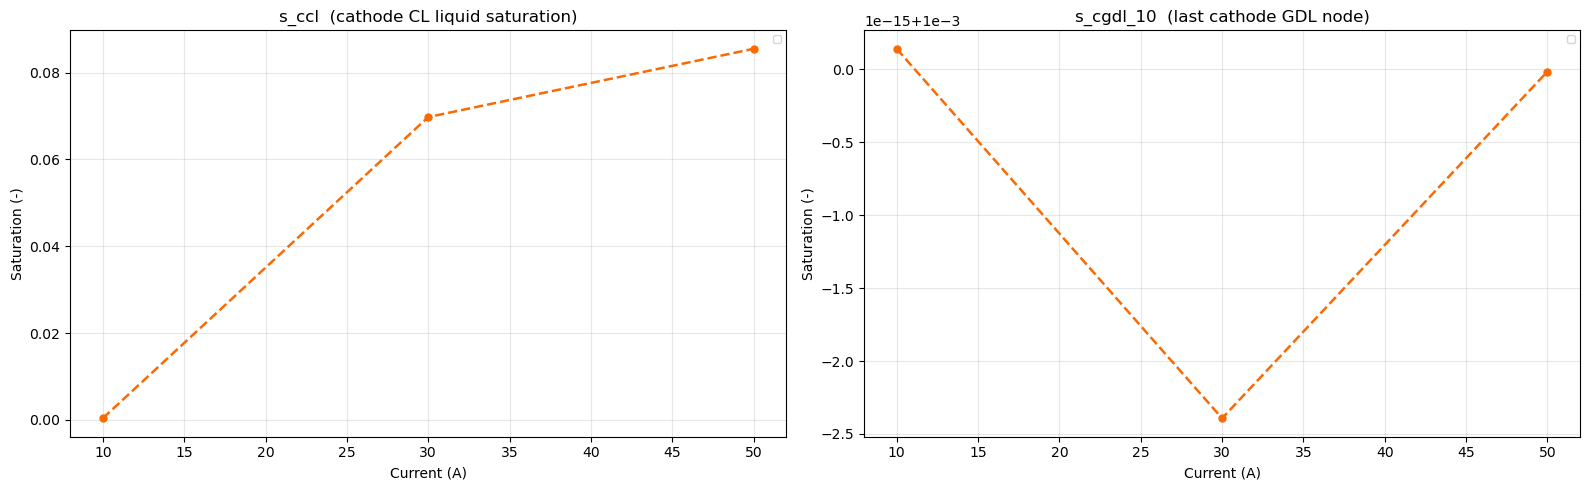

In [11]:
# ---- Cell 10: Saturation in the cathode catalyst layer + GDL ----
fig, ax = plt.subplots(figsize=(16, 5), nrows=1, ncols=2)
for key, value in pola_tests_sim.items():
    i = value.get("i_kept", load_points)
    if "s_ccl" in value["states"]:
        plot_condition(ax[0], i, np.array(value["states"]["s_ccl"], dtype=float),
                       key, linewidth=1.8, markersize=5)
    if "s_cgdl_10" in value["states"]:
        plot_condition(ax[1], i, np.array(value["states"]["s_cgdl_10"], dtype=float),
                       key, linewidth=1.8, markersize=5)

ax[0].set_title("s_ccl  (cathode CL liquid saturation)")
ax[1].set_title("s_cgdl_10  (last cathode GDL node)")
for a in ax:
    a.set_xlabel("Current (A)")
    a.set_ylabel("Saturation (-)")
    a.grid(True, alpha=0.3)
    a.legend(fontsize=7, loc="best")
plt.tight_layout()
plt.show()


### Plot oxygen

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


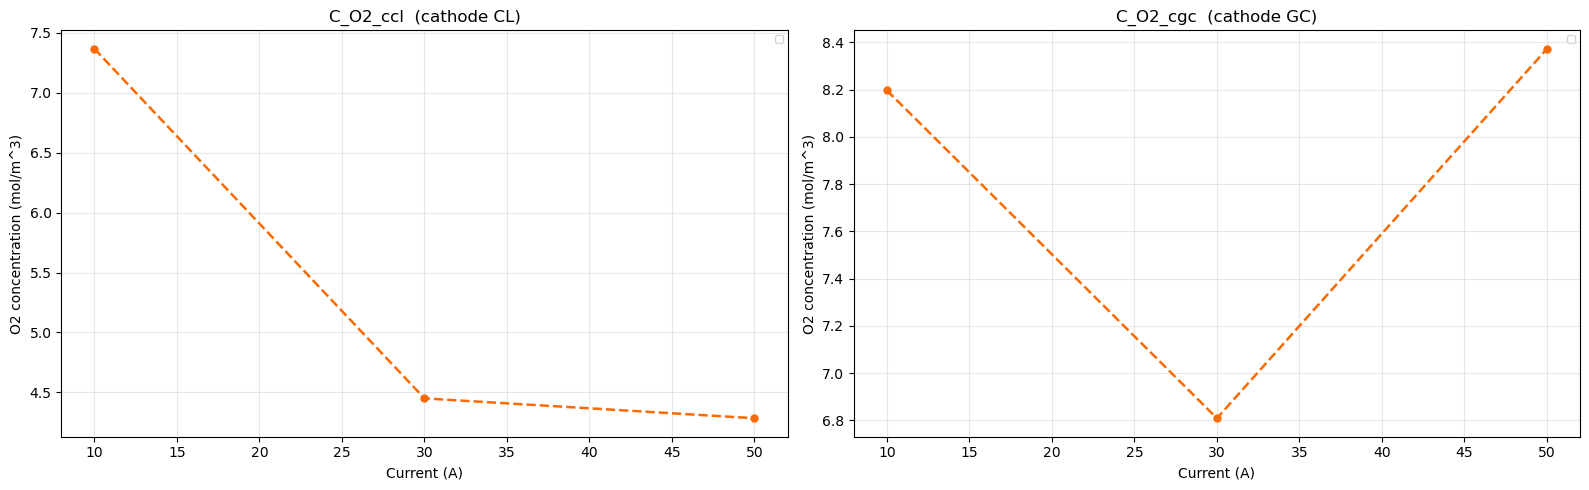

In [12]:
# ---- Cell 12: O2 concentration in cathode CL and gas channel ----
fig, ax = plt.subplots(figsize=(16, 5), nrows=1, ncols=2)
for key, value in pola_tests_sim.items():
    i = value.get("i_kept", load_points)
    if "C_O2_ccl" in value["states"]:
        plot_condition(ax[0], i, np.array(value["states"]["C_O2_ccl"], dtype=float),
                       key, linewidth=1.8, markersize=5)
    if "C_O2_cgc" in value["states"]:
        plot_condition(ax[1], i, np.array(value["states"]["C_O2_cgc"], dtype=float),
                       key, linewidth=1.8, markersize=5)

ax[0].set_title("C_O2_ccl  (cathode CL)")
ax[1].set_title("C_O2_cgc  (cathode GC)")
for a in ax:
    a.set_xlabel("Current (A)")
    a.set_ylabel("O2 concentration (mol/m^3)")
    a.grid(True, alpha=0.3)
    a.legend(fontsize=7, loc="best")
plt.tight_layout()
plt.show()


## GUI-style polarization presentation
Mirrors the result tabs that the Streamlit GUI shows for a polarization test profile, adapted to a per-current snapshot:
1. Polar curve (Cell performance tab)
2. Spatial profile across the MEA (Spatial profile tab)
3. Manifold pressures and humidities (Manifolds tab)
4. Water content (Water content tab)

Each plot puts current on the x-axis and uses `plot_condition` for the colour / linestyle / marker mapping across (T, P, RHC) conditions.


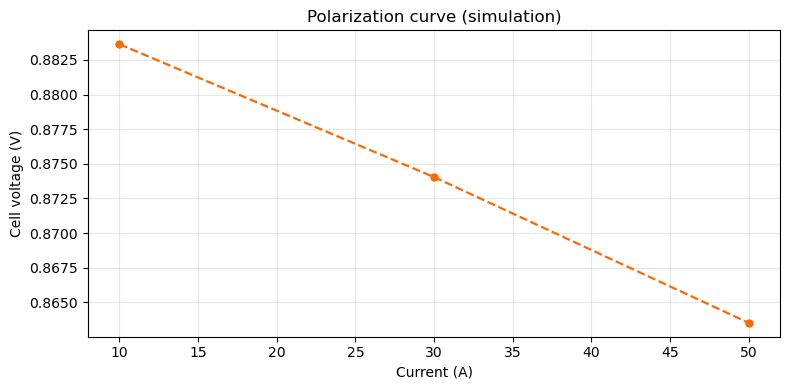

In [13]:
# 1. Polar curve  -- analogue of the GUI's "Cell performance" tab.
# Rebuild Ucell = Ueq - eta_c - i * (sum(Rmem) + Re) from the per-current snapshot.
fig, ax = plt.subplots(figsize=(8, 4))
for cond_key, value in pola_tests_sim.items():
    states = value["states"]
    Ucell = []
    for k in range(len(value.get("i_kept", load_points)) if "value" in dir() else len(load_points)):
        Rmem_total = float(np.sum(states["Rmem"][k]))
        Ucell.append(states["Ueq"][k]
                     - states["eta_c"][k]
                     - states["i_fc"][k] * (Rmem_total + parameters["Re"]))
    plot_condition(ax, value.get("i_kept", load_points), Ucell, cond_key, linewidth=1.6, markersize=5)
ax.set_title("Polarization curve (simulation)")
ax.set_xlabel("Current (A)")
ax.set_ylabel("Cell voltage (V)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


IndexError: list index out of range

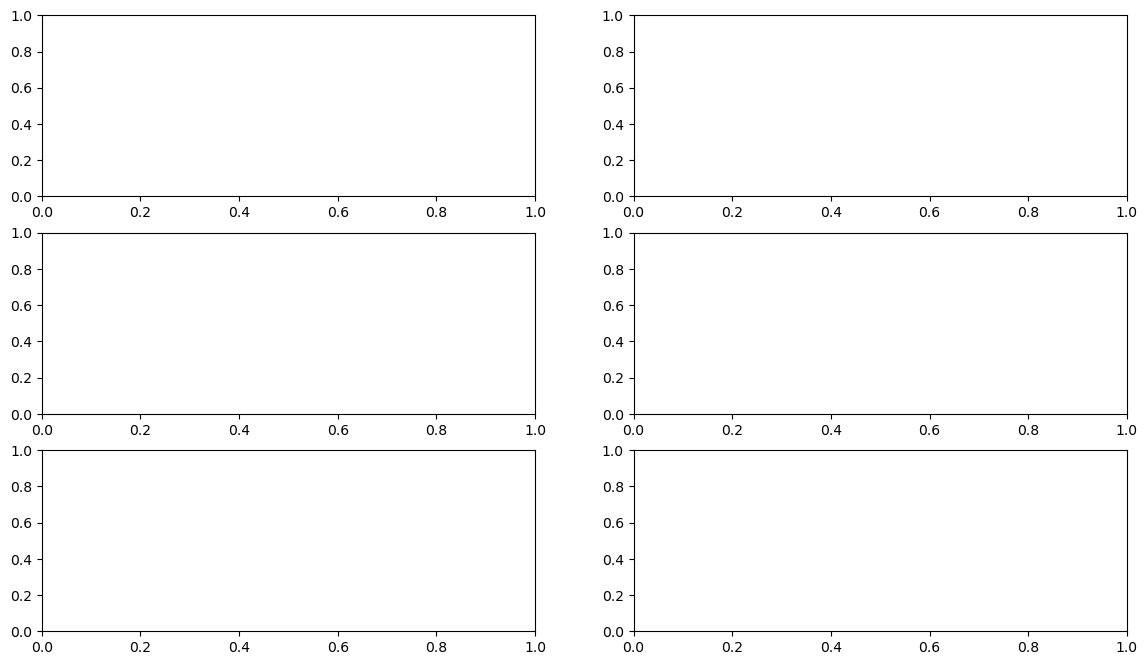

In [14]:
# 2. Spatial profile across the MEA at the highest tested current --
# analogue of the GUI's "Spatial profile" tab (modules.display.build_profile_figure),
# but draws one curve per (T, P, RHC) condition instead of one time index.
profile_panels = [
    ("v",          nodes_names_vp, "Vapor (mol/m$^3$)"),
    ("O2",         nodes_name_O2,  "Oxygen (mol/m$^3$)"),
    ("H2",         nodes_names_H2, "Hydrogen (mol/m$^3$)"),
    ("saturation", nodes_names_s,  "Liquid saturation (-)"),
    ("lambda",     nodes_lambda,   r"Water content $\lambda$ (-)"),
    ("T",          nodes_T,        "Temperature (K)"),
]
last_idx = len(load_points) - 1
fig, axes = plt.subplots(figsize=(14, 8), nrows=3, ncols=2)
for ax, (key, var_list, ylabel) in zip(axes.flatten(), profile_panels):
    for cond_key, value in pola_tests_sim.items():
        compact = [value["states"][n][last_idx] for n in var_list]
        expanded = expand_profile_on_nodes(key, compact)
        plot_condition(ax, nodes, expanded, cond_key, linewidth=1.3, markersize=3)
    for x in borders:
        ax.axvline(x=x, color="0.7", linestyle="--", linewidth=0.7, alpha=0.7)
    ax.set_xlabel("x (m)")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
fig.suptitle(f"Spatial profile at I = {load_points[-1]} A", fontsize=11)
plt.tight_layout()
plt.show()


In [ ]:
# 3. Manifold pressures and humidities vs current --
# analogue of the GUI's "Manifolds" tab (2 x 4 = 8 panels).
manifold_vars = [
    ("Phi_asm", "Anode supply RH (-)"),
    ("Pasm",    "Anode supply pressure (Pa)"),
    ("Phi_csm", "Cathode supply RH (-)"),
    ("Pcsm",    "Cathode supply pressure (Pa)"),
    ("Phi_aem", "Anode exhaust RH (-)"),
    ("Paem",    "Anode exhaust pressure (Pa)"),
    ("Phi_cem", "Cathode exhaust RH (-)"),
    ("Pcem",    "Cathode exhaust pressure (Pa)"),
]
fig, axes = plt.subplots(figsize=(14, 6), nrows=2, ncols=4)
for ax, (var, title) in zip(axes.flatten(), manifold_vars):
    for cond_key, value in pola_tests_sim.items():
        if var not in value["states"]:
            continue
        plot_condition(ax, value.get("i_kept", load_points), value["states"][var], cond_key, linewidth=1.4, markersize=4)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("Current (A)")
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# 4. Water content -- analogue of the GUI's "Water content" tab.
# Lambda in each CL vs current, plus a heatmap of the per-node membrane
# lambda at I = max (one row per condition).
fig, axes = plt.subplots(figsize=(12, 3), nrows=1, ncols=2)
for cond_key, value in pola_tests_sim.items():
    plot_condition(axes[0], value.get("i_kept", load_points), value["states"]["lambda_acl"], cond_key, linewidth=1.4)
    plot_condition(axes[1], value.get("i_kept", load_points), value["states"]["lambda_ccl"], cond_key, linewidth=1.4)
for ax, t in zip(axes, ("Anode CL", "Cathode CL")):
    ax.set_title(f"{t} water content")
    ax.set_xlabel("Current (A)")
    ax.set_ylabel(r"$\lambda$ (-)")
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

mem_keys = [f"lambda_mem_{i+1}" for i in range(parameters["n_mem"])]
last_idx = len(load_points) - 1
mat = np.array([[value["states"][k][last_idx] for k in mem_keys]
                for value in pola_tests_sim.values()])
fig, ax = plt.subplots(figsize=(8, max(2.5, 0.35 * len(pola_tests_sim))))
im = ax.imshow(mat, aspect="auto", origin="lower", cmap="cividis")
ax.set_yticks(range(len(pola_tests_sim)))
ax.set_yticklabels(list(pola_tests_sim.keys()), fontsize=8)
ax.set_xlabel("Membrane node")
ax.set_title(f"Membrane water content $\\lambda$ at I = {load_points[-1]} A")
fig.colorbar(im, ax=ax, label=r"$\lambda$ (-)")
plt.tight_layout()
plt.show()
